In [47]:
import jax.numpy as jnp
import numpy as np
import jax
import jax.random as jr
import arviz as az
# Import the custom package you generated
from Better_HMC import HMCSampler 
import matplotlib.pyplot as plt
#jax.config.update("jax_enable_x64", True)

num_dimensions = 50
num_data = 100
noise_magnitude_on_each_point = 0.1
total_length = 1
def matern_32(r, logscale, variance=1.0, jitter=1e-6):
    scale = jnp.exp(logscale)
    result = variance * (1 + jnp.sqrt(3)*r/scale)*jnp.exp(-1*jnp.sqrt(3)*r/scale);
    return jnp.where(r > 0, result, result * (1.0 + jitter))

def rbf_kernel(r, logscale, variance=1.0, jitter=1e-6):
    scale = jnp.exp(logscale)
    result = variance * jnp.exp(-1/2 * (r/scale)**2)
    return jnp.where(r > 0, result, result * (1.0 + jitter))


def dist_function(i, j):
    return jnp.abs(i - j)*total_length/(num_dimensions - 1)

fixed_points_linspace = jnp.linspace(0, total_length, num_dimensions)
shape = (num_dimensions, num_dimensions)
dist_matrix = jnp.fromfunction(dist_function, shape)

diagonal_values = jnp.ones(num_data)*noise_magnitude_on_each_point**2
def cov_kernel(scale):
    return rbf_kernel(dist_matrix, scale)
cov_data_matrix = jnp.diag(diagonal_values)
inv_cov_data_matrix = jnp.linalg.inv(cov_data_matrix)

k1, k2 = jr.split(jr.key(90))
x_obs = jr.uniform(k1, shape=(num_data,), minval=0.0, maxval=total_length)
y_obs_true = jnp.sin(30*x_obs) * jnp.exp(-5*x_obs)
y_obs_err = noise_magnitude_on_each_point * jnp.ones_like(y_obs_true)

y_obs = y_obs_true + y_obs_err * jr.normal(k2, shape=y_obs_true.shape)

def response(model_values):
    return jnp.interp(x_obs, fixed_points_linspace, model_values)


#observed_indices = jnp.searchsorted(fixed_points_linspace, x_obs)
#R = jnp.zeros((num_data, num_dimensions));
#R = R.at[jnp.arange(num_data), observed_indices].set(1);
R = jax.jacobian(response)(fixed_points_linspace)

#D = cov_prior_matrix - cov_prior_matrix @ R.T @ jnp.linalg.inv(R @ cov_prior_matrix @ R.T + cov_data_matrix) @ R @ cov_prior_matrix;
#M = cov_prior_matrix @ R.T @ jnp.linalg.inv(R @ cov_prior_matrix @ R.T + cov_data_matrix) @ y_obs
#L_D = jnp.linalg.cholesky(D)
def KL_div_between_two_Gaussians(x1, cov1, x2, cov2, num_dimensions):
    L2 = jnp.linalg.cholesky(cov2)
    
    # logdet via Cholesky: logdet(cov2) = 2 * sum(log(diag(L2)))
    logabsdet2 = 2.0 * jnp.sum(jnp.log(jnp.diag(L2)))
    _, logabsdet1 = jnp.linalg.slogdet(cov1)
    
    # trace(cov2^-1 @ cov1) via triangular solves instead of full solve
    solve1 = jax.scipy.linalg.cho_solve((L2, True), cov1)
    trace_term = jnp.trace(solve1)
    
    # mahalanobis term via triangular solve
    diff = x2 - x1
    y = jax.scipy.linalg.solve_triangular(L2, diff, lower=True)
    mahalanobis = jnp.sum(y**2)  # equivalent to y.T @ y, avoids the solve
    
    return 0.5 * (logabsdet2 - logabsdet1 - num_dimensions
                  + trace_term + mahalanobis)


In [48]:
def logscaleprior(logscale):
    return jnp.exp(-0.5*logscale**2)

In [49]:
num_overall_steps = 10000
burn_in = 0
def negative_logdensity(x):
    field_values = x[1:]
    logscale = x[0]
    cov_prior = cov_kernel(logscale)
    # L_K = jnp.linalg.cholesky(cov_prior)
    # R_enhanced = R @ L_K
    negative_log_p_d_given_s_and_scale = 0.5*(y_obs - R @ field_values).T @ inv_cov_data_matrix @ (y_obs - R @ field_values) 
    negative_log_p_s_given_scale = 0.5*field_values.T @ jnp.linalg.solve(cov_prior, field_values)
    negative_log_p_scale = -logscaleprior(logscale)
    return negative_log_p_d_given_s_and_scale + negative_log_p_s_given_scale + negative_log_p_scale

sampler = HMCSampler(
    negative_logdensity=negative_logdensity,
    num_integration_steps=10,
    step_size=0.0001,
    inv_mass_matrix = jnp.eye(num_dimensions + 1),
    alpha=1.0
)

# 3. Setup execution seed and coordinates, then run!
rng = jr.PRNGKey(2)
initial_coordinates = jnp.zeros(num_dimensions + 1)
initial_coordinates = initial_coordinates.at[0].set(-4)

overall_position_arr, overall_momentum_arr, accept_prob_arr = sampler.sample(
    start_position=initial_coordinates, 
    num_samples=num_overall_steps,
    burn_in = burn_in,
    rng_key=rng
)

overall_position_arr = overall_position_arr[:, 1:]  

[ 0.00038149  0.0009336  -0.00043383 ...  0.18268356  0.18205231
  0.18300052]
[0.99998474 1.         0.99998474 ... 0.9999924  1.         0.9999924 ]


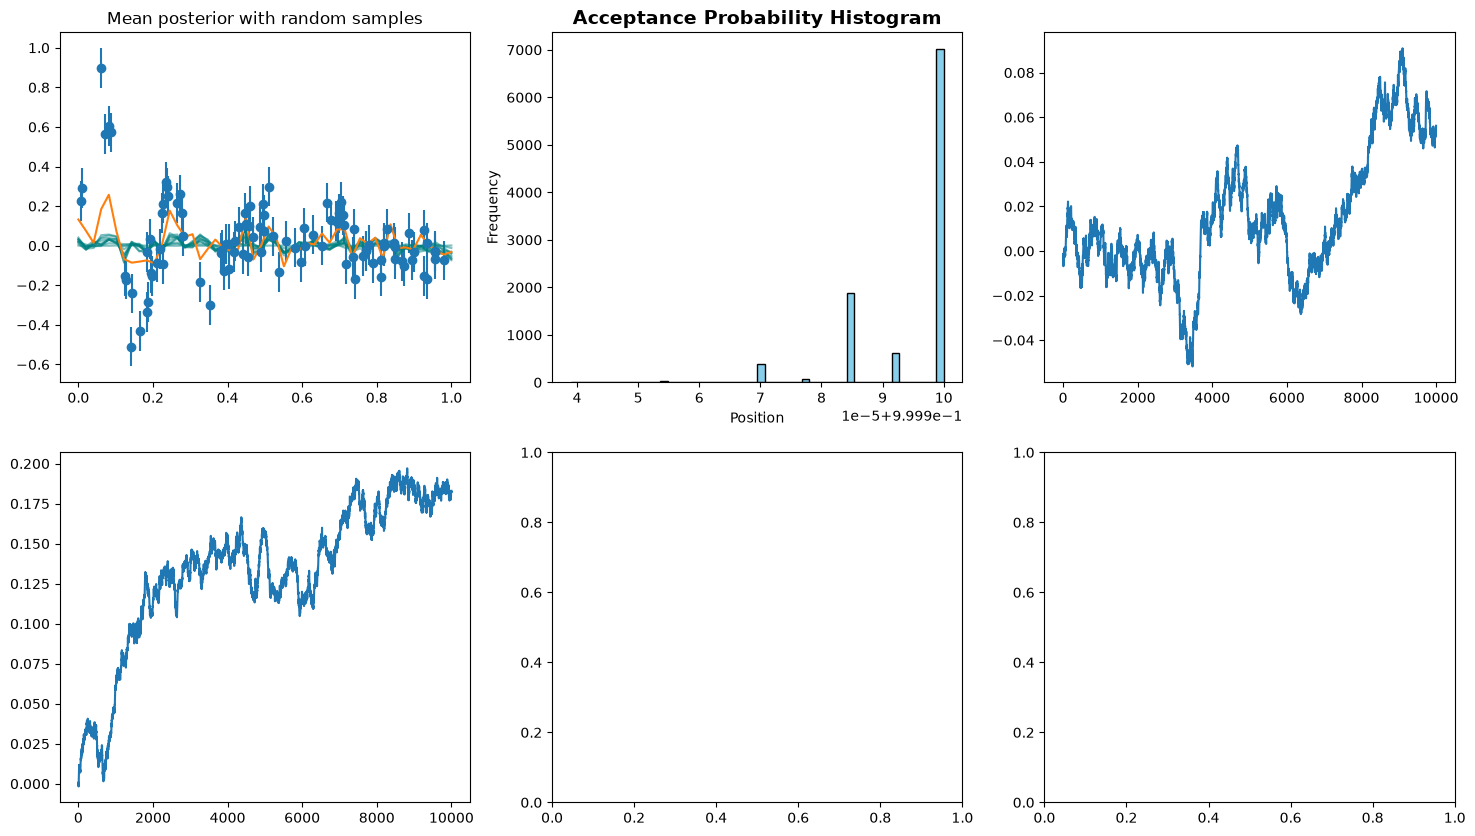

In [53]:
print(overall_position_arr[:, 0])
print(accept_prob_arr)


num_good_samples = num_overall_steps - burn_in
time_arr = jnp.arange(num_good_samples)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
mean_position = overall_position_arr.sum(axis=0)/num_good_samples
axes[0][0].errorbar(x_obs, y_obs, yerr=y_obs_err, fmt='o', label='Observations')

for i in range (0, 10):
    axes[0][0].plot(fixed_points_linspace, overall_position_arr[100*i, :], color = "teal", alpha = 0.5);
axes[0][0].plot(fixed_points_linspace, mean_position)
axes[0][0].set_title("Mean posterior with random samples")

axes[0][1].hist(accept_prob_arr, bins=50, edgecolor='black', color='skyblue')

# Add labels and a title to make it readable
axes[0][1].set_title('Acceptance Probability Histogram', fontsize=14, fontweight='bold')
axes[0][1].set_xlabel('Position')
axes[0][1].set_ylabel('Frequency')

axes[0][2].plot(time_arr, overall_position_arr[:, 30])
axes[1][0].plot(time_arr, scales)